In [1]:
import numpy as np
import pandas as pd


np.random.seed(42)

In [2]:
# Tạo mã khách hàng
ma_kh = [f"KH{i:03d}" for i in range(1, 501)]

# Tuổi từ 18-70
tuoi = np.random.randint(18, 71, 500).astype(float)

# Chèn 10 giá trị NaN
nan_index = np.random.choice(500, 10, replace=False)
tuoi[nan_index] = np.nan

# Thu nhập (5 - 50 triệu)
thu_nhap = np.random.uniform(5_000_000, 50_000_000, 500)

# Chèn 5 outlier lên đến 200 triệu
outlier_index = np.random.choice(500, 5, replace=False)
thu_nhap[outlier_index] = np.random.uniform(150_000_000, 200_000_000, 5)

# Giới tính
gioi_tinh = np.random.choice(['Nam', 'Nữ'], 500).astype(object)

# Chèn 15 giá trị NaN
nan_gt = np.random.choice(500, 15, replace=False)
gioi_tinh[nan_gt] = np.nan

# Thành phố
thanh_pho = np.random.choice(
    ['Hà Nội', 'Đà Nẵng', 'TP.HCM'],
    500
)

# Tổng chi tiêu (tương quan nhẹ với thu nhập)
tong_chi_tieu = thu_nhap * np.random.uniform(0.3, 0.8, 500)

# Tạo DataFrame
df_khachhang = pd.DataFrame({
    'MaKH': ma_kh,
    'Tuoi': tuoi,
    'ThuNhap': thu_nhap,
    'GioiTinh': gioi_tinh,
    'ThanhPho': thanh_pho,
    'TongChiTieu': tong_chi_tieu
})

df_khachhang.head()

,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu
0,KH001,56.0,1.986568e+07,NaN,Hà Nội,1.033454e+07
1,KH002,69.0,4.701613e+07,Nam,TP.HCM,2.121211e+07
2,KH003,46.0,5.339046e+06,Nam,Hà Nội,2.294014e+06
3,KH004,32.0,1.513998e+07,Nữ,TP.HCM,6.015293e+06
4,KH005,60.0,2.144106e+07,Nam,Hà Nội,7.050330e+06


In [3]:
print(df_khachhang.info())

print("\n5 dòng đầu tiên:")
display(df_khachhang.head())

print("\n5 dòng cuối:")
display(df_khachhang.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MaKH         500 non-null    object 
 1   Tuoi         490 non-null    float64
 2   ThuNhap      500 non-null    float64
 3   GioiTinh     485 non-null    object 
 4   ThanhPho     500 non-null    object 
 5   TongChiTieu  500 non-null    float64
dtypes: float64(3), object(3)
memory usage: 23.6+ KB
None

5 dòng đầu tiên:


,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu
0,KH001,56.0,1.986568e+07,NaN,Hà Nội,1.033454e+07
1,KH002,69.0,4.701613e+07,Nam,TP.HCM,2.121211e+07
2,KH003,46.0,5.339046e+06,Nam,Hà Nội,2.294014e+06
3,KH004,32.0,1.513998e+07,Nữ,TP.HCM,6.015293e+06
4,KH005,60.0,2.144106e+07,Nam,Hà Nội,7.050330e+06



5 dòng cuối:


,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu
495,KH496,43.0,4.467367e+07,Nữ,Hà Nội,1.434968e+07
496,KH497,70.0,4.825919e+07,Nam,Đà Nẵng,2.087997e+07
497,KH498,40.0,2.594615e+07,Nam,Hà Nội,1.558785e+07
498,KH499,26.0,4.455822e+07,Nữ,TP.HCM,1.997456e+07
499,KH500,29.0,5.231533e+06,Nữ,TP.HCM,3.438226e+06


In [4]:
print("Số lượng giá trị khuyết của từng cột:\n")
print(df_khachhang.isnull().sum())


Số lượng giá trị khuyết của từng cột:

MaKH            0
Tuoi           10
ThuNhap         0
GioiTinh       15
ThanhPho        0
TongChiTieu     0
dtype: int64


In [5]:
# Điền Tuoi bằng Median
median_tuoi = df_khachhang['Tuoi'].median()
df_khachhang['Tuoi'].fillna(median_tuoi, inplace=True)

# Điền GioiTinh bằng Mode
mode_gioitinh = df_khachhang['GioiTinh'].mode()[0]
df_khachhang['GioiTinh'].fillna(mode_gioitinh, inplace=True)

print("Đã xử lý giá trị khuyết.")


Đã xử lý giá trị khuyết.


/tmp/ipykernel_1366/3500328818.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_khachhang['Tuoi'].fillna(median_tuoi, inplace=True)
/tmp/ipykernel_1366/3500328818.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [6]:
print("Sau khi xử lý:\n")
print(df_khachhang.isnull().sum())

Sau khi xử lý:

MaKH           0
Tuoi           0
ThuNhap        0
GioiTinh       0
ThanhPho       0
TongChiTieu    0
dtype: int64


In [7]:
# One-Hot Encoding
df_city = pd.get_dummies(
    df_khachhang['ThanhPho'],
    prefix='TP'
)

# Ghép vào DataFrame
df_khachhang = pd.concat(
    [df_khachhang, df_city],
    axis=1
)

df_khachhang.head()

,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,TP_Hà Nội,TP_TP.HCM,TP_Đà Nẵng
0,KH001,56.0,1.986568e+07,Nữ,Hà Nội,1.033454e+07,True,False,False
1,KH002,69.0,4.701613e+07,Nam,TP.HCM,2.121211e+07,False,True,False
2,KH003,46.0,5.339046e+06,Nam,Hà Nội,2.294014e+06,True,False,False
3,KH004,32.0,1.513998e+07,Nữ,TP.HCM,6.015293e+06,False,True,False
4,KH005,60.0,2.144106e+07,Nam,Hà Nội,7.050330e+06,True,False,False


In [8]:
print(df_khachhang.columns)

Index(['MaKH', 'Tuoi', 'ThuNhap', 'GioiTinh', 'ThanhPho', 'TongChiTieu',
       'TP_Hà Nội', 'TP_TP.HCM', 'TP_Đà Nẵng'],
      dtype='object')


In [9]:
Q1 = df_khachhang['ThuNhap'].quantile(0.25)
Q3 = df_khachhang['ThuNhap'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("Lower:", lower)
print("Upper:", upper)

Q1: 17487805.590331566
Q3: 39697300.00766945
Lower: -15826436.035675261
Upper: 73011541.63367628


In [10]:
# Lọc bỏ outlier
df_khachhang = df_khachhang[
    (df_khachhang['ThuNhap'] >= lower) &
    (df_khachhang['ThuNhap'] <= upper)
]

print("Số dòng còn lại:", len(df_khachhang))

Số dòng còn lại: 495


In [11]:
from sklearn.preprocessing import MinMaxScaler

# Khởi tạo scaler
scaler = MinMaxScaler()

# Chuẩn hóa
df_khachhang['TongChiTieu_Scaled'] = scaler.fit_transform(
    df_khachhang[['TongChiTieu']]
)

# Hiển thị kết quả
df_khachhang[['TongChiTieu', 'TongChiTieu_Scaled']].head()

,TongChiTieu,TongChiTieu_Scaled
0,1.033454e+07,0.230982
1,2.121211e+07,0.517732
2,2.294014e+06,0.019021
3,6.015293e+06,0.117120
4,7.050330e+06,0.144405


In [12]:
print(df_khachhang['TongChiTieu_Scaled'].min())
print(df_khachhang['TongChiTieu_Scaled'].max())

0.0
0.9999999999999999


In [13]:
df_nu_hanoi = df_khachhang[
    (df_khachhang['GioiTinh'] == 'Nữ') &
    (df_khachhang['Tuoi'] > 30) &
    (df_khachhang['ThanhPho'] == 'Hà Nội')
]

df_nu_hanoi.head()

,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,TP_Hà Nội,TP_TP.HCM,TP_Đà Nẵng,TongChiTieu_Scaled
0,KH001,56.0,1.986568e+07,Nữ,Hà Nội,1.033454e+07,True,False,False,0.230982
16,KH017,41.0,3.091993e+07,Nữ,Hà Nội,2.464084e+07,True,False,False,0.608119
18,KH019,39.0,5.238500e+06,Nữ,Hà Nội,3.204406e+06,True,False,False,0.043021
19,KH020,70.0,4.887802e+07,Nữ,Hà Nội,2.857843e+07,True,False,False,0.711920
21,KH022,41.0,3.753032e+07,Nữ,Hà Nội,1.503675e+07,True,False,False,0.354940


In [14]:
thong_ke = df_khachhang.groupby("ThanhPho")["TongChiTieu"].agg(
    Mean="mean",
    Sum="sum"
)

thong_ke

,Mean,Sum
ThanhPho,,
Hà Nội,1.543058e+07,2.808366e+09
TP.HCM,1.616383e+07,2.650867e+09
Đà Nẵng,1.561829e+07,2.327126e+09


In [16]:
bins = [18, 30, 45, 60, 100]

labels = [
    "18-30",
    "31-45",
    "46-60",
    "Trên 60"
]

df_khachhang["NhomTuoi"] = pd.cut(
    df_khachhang["Tuoi"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [17]:
df_khachhang[
    ["Tuoi", "NhomTuoi"]
].head(10)

,Tuoi,NhomTuoi
0,56.0,46-60
1,69.0,Trên 60
2,46.0,46-60
3,32.0,31-45
4,60.0,46-60
5,25.0,18-30
6,38.0,31-45
7,56.0,46-60
8,36.0,31-45
9,40.0,31-45


In [18]:
print(df_khachhang["NhomTuoi"].value_counts())

NhomTuoi
31-45      151
46-60      139
18-30      107
Trên 60     98
Name: count, dtype: int64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_khachhang[
    ['Tuoi', 'ThuNhap', 'TongChiTieu']
].corr(method='pearson')

print(corr)

                 Tuoi   ThuNhap  TongChiTieu
Tuoi         1.000000 -0.037474    -0.014109
ThuNhap     -0.037474  1.000000     0.853854
TongChiTieu -0.014109  0.853854     1.000000


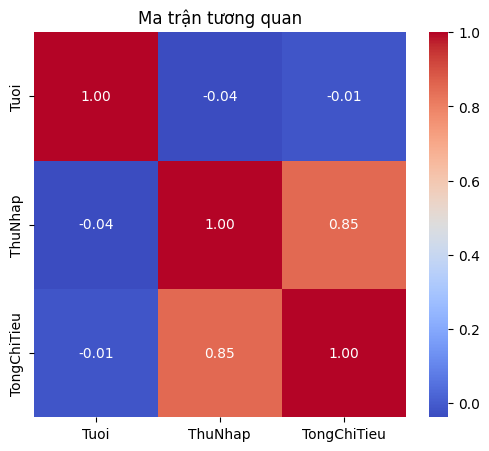

In [20]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Ma trận tương quan")
plt.show()

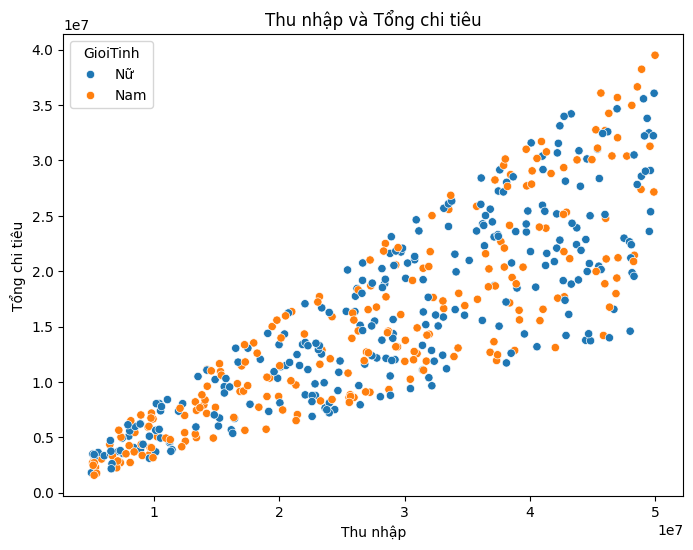

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_khachhang,
    x="ThuNhap",
    y="TongChiTieu",
    hue="GioiTinh"
)

plt.title("Thu nhập và Tổng chi tiêu")
plt.xlabel("Thu nhập")
plt.ylabel("Tổng chi tiêu")

plt.show()

In [22]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [23]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(x_train.shape)
print(x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


In [24]:
# Chuẩn hóa pixel
x_train = x_train / 255.0
x_test = x_test / 255.0

# Thêm kênh màu
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print(x_train.shape)

(60000, 28, 28, 1)


In [25]:
model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(

    x_train,
    y_train,

    epochs=5,

    validation_split=0.2,

    batch_size=32

)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.8379 - loss: 0.4524 - val_accuracy: 0.8829 - val_loss: 0.3309
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.8918 - loss: 0.3033 - val_accuracy: 0.8856 - val_loss: 0.3177
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9069 - loss: 0.2587 - val_accuracy: 0.9039 - val_loss: 0.2691
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9161 - loss: 0.2280 - val_accuracy: 0.9092 - val_loss: 0.2570
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9257 - loss: 0.2034 - val_accuracy: 0.9115 - val_loss: 0.2498


In [28]:
loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("Loss:", loss)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9024 - loss: 0.2673
Loss: 0.2673288881778717
Accuracy: 0.902400016784668


In [29]:
import numpy as np

predict = model.predict(x_test)

print("Nhãn dự đoán:", np.argmax(predict[0]))
print("Nhãn thực:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Nhãn dự đoán: 9
Nhãn thực: 9


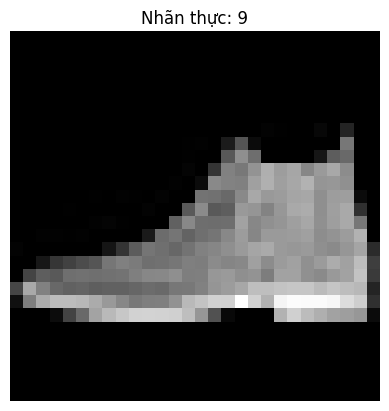

In [30]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Nhãn thực: {y_test[0]}")
plt.axis("off")
plt.show()